In [1]:
import awkward as ak
import vector
vector.register_awkward()
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import hist
import mplhep as hep
import pandas as pd
hep.style.ROOT
import matplotlib.cm as cm
from scipy.optimize import curve_fit
import sys
sys.path.insert(0, '../scripts')
from plotting import *
from common_defs import *
print(matplotlib.__version__)

%load_ext autoreload
%autoreload 2

Masking out zero values to fix different lengths:  (100000,) (100000,) (99996,)
Masking out zero values to fix different lengths:  (100000,) (100000,) (99996,)
Masking out zero values to fix different lengths:  (100000,) (100000,) (99996,)
TTbar frac values [0.   0.   0.25 0.42 0.53 0.94]
TTbar jeppe v0 frac values [-0.64, -0.63, -0.62, -0.61, -0.59, -0.58, -0.56, -0.53, -0.51, -0.48, -0.45, -0.41, -0.37, -0.33, -0.3, -0.25, -0.21, -0.16, -0.11, -0.05, -0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.31, 0.35, 0.4, 0.45, 0.49, 0.54, 0.57, 0.61, 0.65, 0.68, 0.72, 0.74, 0.77, 0.79, 0.82, 0.84, 0.86, 0.88, 0.89, 0.91, 0.92, 0.93, 0.94, 0.95]
3.10.8


In [2]:
def get_lb_pair(jets, leptons, bhadrons):
    
    jets_sel = jets[jets.pt > 30]
    
    # Build Jet x Bhadron pairs: events -> jets -> bhadrons
    pairs_jb = ak.cartesian(
        {"j": jets_sel, "bh": bhadrons},
        axis=1,
        nested=True,
    )
    
    dr_jb = pairs_jb["j"].deltaR(pairs_jb["bh"])
    
    has_bhadron = ak.any(dr_jb < 0.4, axis=2)
    
    bjets = jets_sel[has_bhadron]
    
    leptons_sel = leptons[leptons.pt > 25]
    
    # events -> leptons -> bjets
    pairs_lb = ak.cartesian(
        {"l": leptons_sel, "b": bjets},
        axis=1,
        nested=True,
    )
    
    dr_lb = ak.fill_none(pairs_lb["l"].deltaR(pairs_lb["b"]), np.inf)
    idx = ak.argmin(dr_lb, axis=2)                 # events→L
    best_b = bjets[idx]
    drmin_lb = ak.min(dr_lb, axis=2, initial=np.inf)

    valid_pair = (
    ~ak.is_none(best_b, axis=1)
    & (drmin_lb > 0.4)
    )

    sel = ak.any(valid_pair, axis=1)
    
    m_lb = (leptons_sel + best_b).mass
    m_lb = m_lb[valid_pair]
    
    return m_lb[sel, 0], sel

In [3]:
ttbar_jets = ak.from_parquet(lhayDir + '/ttbar_NLO_100k_eta4p5_pt20.parquet')
order = ak.argsort(ttbar_jets.pt, axis=1, ascending=False)
jets = ttbar_jets[order]

bhadrons = ak.from_parquet(lhayDir + '/ttbar_100k/ttbar_NLO_100k_bhadrons.parquet')
leptons = ak.from_parquet(lhayDir + '/ttbar_100k/ttbar_NLO_100k_leptons.parquet')



In [23]:
obsDict = {}
njets = max(ak.num(jets.pt, axis=1))-1

nosel = (ak.num(jets.pt, axis=1)>-5)

sel_twojets = (ak.num(jets.pt, axis=1)>1)
sel_jets_twojets = jets[sel_twojets]

sel_onejet = (ak.num(jets.pt, axis=1)>0)
sel_jets_onejet = jets[sel_onejet]

mlb, sel_lb = get_lb_pair(jets, leptons, bhadrons)

quantity="m_{tt}"
sel_ttjets = (ak.num(jets.pt, axis=1)>5)
had_jets = jets[sel_ttjets]
ttjets = ak.sum(had_jets, axis = -1)
mtt = ttjets.mass


# obsDict["drjj"] = {"name": r"\Delta R_{j_0, j_1}","units": "", "xmin": 0, "xmax": 10, "numbins": 20, "ratioLim": [0.75,1.25], "obs": np.sqrt((sel_jets_twojets.eta[:,0] - sel_jets_twojets.eta[:,1])**2 + (sel_jets_twojets.phi[:,0] - sel_jets_twojets.phi[:,1])**2), "sel":sel_twojets, "logx":False, "logy": True, "binwnorm":None}
# obsDict["njets"] = {"name": r'N_{\mathrm{jets}}', "xmin": 0, "xmax": 20,"units": r"", "xmax": njets,"numbins": njets, "ratioLim": [0.75,1.25], "obs": ak.num(jets.pt, axis=1), "sel":nosel, "logx":False, "logy": True, "ymin": 1e-4, "ymax": 1.5, "binwnorm":None}
# obsDict["ptlead"] = {"name": "p_{T,j_0}", "xmin": 20,"units": r"\mathrm{[GeV]}", "xmax": 500, "numbins": 20, "ratioLim": [0.75,1.25], "obs": sel_jets_onejet.pt[:,0], "sel": sel_onejet, "logx":False, "logy": True, "binwnorm":None}
# obsDict["ht"] = {"name": r'H_\mathrm{T}', "xmin": 50, "xmax": 2500,"units": r"\mathrm{[GeV]}", "numbins": 20, "ratioLim": [0.75,1.25], "obs": ak.sum(jets.pt, axis=-1), "sel": nosel, "logx":True, "logy": True, "ymin": 1e-4, "ymax": 2.5, "binwnorm":None}
# obsDict["mtt"] = {"name": "m_{tt}", "xmin": 0, "xmax": 2000,"units": r"\mathrm{[GeV]}", "numbins": 20, "ratioLim": [0.75,1.25], "obs": mtt, "sel": sel_ttjets, "logx":False, "logy": False, "ymin": 0, "ymax": 0.2, "binwnorm":None}
# obsDict["mlb"] = {"name": "m_{lb}", "xmin": 0, "xmax": 250,"units": r"\mathrm{[GeV]}", "numbins": 24, "ratioLim": [0.75,1.25], "obs": mlb, "sel": sel_lb, "logx":False, "logy": False, "ymin": 1e-4, "ymax": 0.2, "binwnorm":None}
# obsDict["ptrat"] = {"name": "p_{T0}/p_{T1}", "xmin": 1,"units": r"", "xmax": 4.5, "numbins": 14, "ratioLim": [0.75,1.25], "obs": sel_jets_twojets.pt[:,0]/sel_jets_twojets.pt[:,1], "sel": sel_twojets, "logx":False, "logy": True, "binwnorm":None}
obsDict["drjj"] = {"name": r"\Delta R_{j_0, j_1}","units": "", "xmin": 0, "xmax": 10, "numbins": 20, "ratioLim": [0.75,1.25], "obs": np.sqrt((sel_jets_twojets.eta[:,0] - sel_jets_twojets.eta[:,1])**2 + (sel_jets_twojets.phi[:,0] - sel_jets_twojets.phi[:,1])**2), "sel":sel_twojets, "logx":False, "logy": True, "binwnorm":True,"ymin": 1e-4, "ymax": 0.2,}
obsDict["njets"] = {"name": r'N_{\mathrm{jets}}', "xmin": 0, "xmax": 20,"units": r"", "xmax": njets,"numbins": njets, "ratioLim": [0.75,1.25], "obs": ak.num(jets.pt, axis=1), "sel":nosel, "logx":False, "logy": True, "ymin": 1e-4, "ymax": 1.5, "binwnorm":True}
obsDict["ptlead"] = {"name": "p_{T,j_0}", "xmin": 20,"units": r"\mathrm{[GeV]}", "xmax": 500, "numbins": 20, "ratioLim": [0.75,1.25], "obs": sel_jets_onejet.pt[:,0], "sel": sel_onejet, "logx":False, "logy": True, "binwnorm":True,"ymin": 1e-4, "ymax": 0.2,}
obsDict["ht"] = {"name": r'H_\mathrm{T}', "xmin": 50, "xmax": 2500,"units": r"\mathrm{[GeV]}", "numbins": 20, "ratioLim": [0.75,1.25], "obs": ak.sum(jets.pt, axis=-1), "sel": nosel, "logx":True, "logy": True, "ymin": 1e-4, "ymax": 2.5, "binwnorm":True}
obsDict["mtt"] = {"name": "m_{tt}", "xmin": 0, "xmax": 2000,"units": r"\mathrm{[GeV]}", "numbins": 20, "ratioLim": [0.75,1.25], "obs": mtt, "sel": sel_ttjets, "logx":False, "logy": False, "ymin": 0, "ymax": 0.2, "binwnorm":True}
obsDict["mlb"] = {"name": "m_{lb}", "xmin": 0, "xmax": 250,"units": r"\mathrm{[GeV]}", "numbins": 24, "ratioLim": [0.75,1.25], "obs": mlb, "sel": sel_lb, "logx":False, "logy": False, "ymin": 1e-4, "ymax": 0.2, "binwnorm":True}
obsDict["ptrat"] = {"name": "p_{T0}/p_{T1}", "xmin": 1,"units": r"", "xmax": 4.5, "numbins": 14, "ratioLim": [0.75,1.25], "obs": sel_jets_twojets.pt[:,0]/sel_jets_twojets.pt[:,1], "sel": sel_twojets, "logx":False, "logy": True, "binwnorm":True, "ymin": 1e-4, "ymax": 0.2,}

In [24]:
processDict = {}
processDict["TTbar"] = {"name": r"$t\bar{t}$", "weights": weights_orig_ttbar}

In [25]:
comparisonDict = {}
comparisonDict["stages"] = {"weights": ["ttbar_hp_df", "ttbar_ps_df", "ttbar_had_df"], "maxCellRadius":100}
comparisonDict["EMDvsAndersen"] = {"weights": ["ttbar_had_df", "ttbar_jeppeV3_df", "ttbar_jeppeV2_df", "ttbar_jeppeV1_df"], "maxCellRadius":100}

In [26]:
from plotting import * 
for comparison in comparisonDict:
    rw_dict_strings = comparisonDict[comparison]["weights"]
    datasets = []
    for sample in rw_dict_strings:
        datasets.append(dataFrames[sample])
            
    directory = f"../plots_ttbar/radius"
    plot_radii(datasets, directory, comparison, comparisonDict)

$\beta=1$ HS  R for 0.75 RW  25.968
$\beta=1$ HS  R for 0.5 RW  21.716
$\beta=1$ HS  R for 0.25 RW  18.32
$\beta=1$ PS  R for 0.75 RW  35.951
$\beta=1$ PS  R for 0.5 RW  29.288
$\beta=1$ PS  R for 0.25 RW  23.966
$\beta=1$ HAD  R for 0.75 RW  35.208
$\beta=1$ HAD  R for 0.5 RW  29.521
$\beta=1$ HAD  R for 0.25 RW  24.979
../plots_ttbar/radius/radii_stages
$\beta=1$ HAD  R for 0.75 RW  35.208
$\beta=1$ HAD  R for 0.5 RW  29.521
$\beta=1$ HAD  R for 0.25 RW  24.979
Andersen $et$ $al.$ R for 0.75 RW  453.012
Andersen $et$ $al.$ R for 0.5 RW  345.577
Andersen $et$ $al.$ R for 0.25 RW  259.753
Andersen V2 $et$ $al.$ R for 0.75 RW  464.792
Andersen V2 $et$ $al.$ R for 0.5 RW  360.582
Andersen V2 $et$ $al.$ R for 0.25 RW  277.333
Andersen V1 $et$ $al.$ R for 0.75 RW  522.372
Andersen V1 $et$ $al.$ R for 0.5 RW  408.374
Andersen V1 $et$ $al.$ R for 0.25 RW  317.308
../plots_ttbar/radius/radii_EMDvsAndersen


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

H_orig xs  1.0
$\beta=1$ HS 
RW xs  9797082.707124082
RW xs /  678.6208346399999 14449.974494283308
$\beta=1$ PS 
RW xs  9803097.907538282
RW xs /  678.6208346399999 14458.846471295401
$\beta=1$ HAD 
RW xs  9801297.640780315
RW xs /  678.6208346399999 14456.191210590434
../plots/TTbar/stages_drjj_0p25
H_orig xs  1.0
$\beta=1$ HS 
RW xs  9796394.927372657
RW xs /  678.6208346399999 14448.960069871175
$\beta=1$ PS 
RW xs  9803079.107403902
RW xs /  678.6208346399999 14458.818742483632
$\beta=1$ HAD 
RW xs  9795372.561346577
RW xs /  678.6208346399999 14447.452155378433
../plots/TTbar/stages_drjj_0p75
H_orig xs  0.9999999999999999
$\beta=1$ HS 
RW xs  9873751.390649471
RW xs /  678.6208346399999 14563.055148450549
$\beta=1$ PS 
RW xs  9873751.390649479
RW xs /  678.6208346399999 14563.05514845056
$\beta=1$ HAD 
RW xs  9873751.390649477
RW xs /  678.6208346399999 14563.055148450556
../plots/TTbar/stages_njets_0p25
H_orig xs  0.9999999999999999
$\beta=1$ HS 
RW xs  9873751.390649458
RW xs /

/oscar/home/lhay/cres-distance/notebooks/../scripts/plotting.py:253: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, (ax, rax) = plt.subplots(nrows=2,


H_orig xs  1.0000000000000002
$\beta=1$ HAD 
RW xs  9834056.20031105
RW xs /  678.6208346399999 14504.507670075294
Andersen $et$ $al.$
RW xs  9781419.698040007
RW xs /  678.6208346399999 14426.872710973461
Andersen V2 $et$ $al.$
RW xs  9777745.665309854
RW xs /  678.6208346399999 14421.453783642852
Andersen V1 $et$ $al.$
RW xs  9778120.830434378
RW xs /  678.6208346399999 14422.00712453448
../plots/TTbar/EMDvsAndersen_ht_0p25
H_orig xs  1.0000000000000002
$\beta=1$ HAD 
RW xs  9833284.050369676
RW xs /  678.6208346399999 14503.36880585498
Andersen $et$ $al.$
RW xs  9787014.716809774
RW xs /  678.6208346399999 14435.124951046864
Andersen V2 $et$ $al.$
RW xs  9785669.47980482
RW xs /  678.6208346399999 14433.140825670826
Andersen V1 $et$ $al.$
RW xs  9785195.104810273
RW xs /  678.6208346399999 14432.441157537276
../plots/TTbar/EMDvsAndersen_ht_0p75
H_orig xs  1.0
$\beta=1$ HAD 
RW xs  4751723.459741557
RW xs /  678.6208346399999 7008.441681034745
Andersen $et$ $al.$
RW xs  4803023.10744

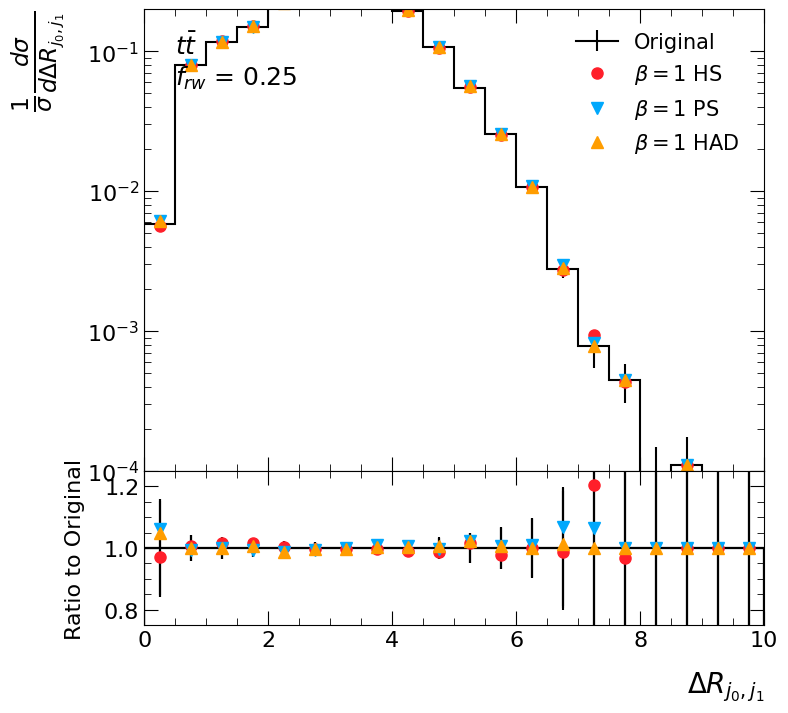

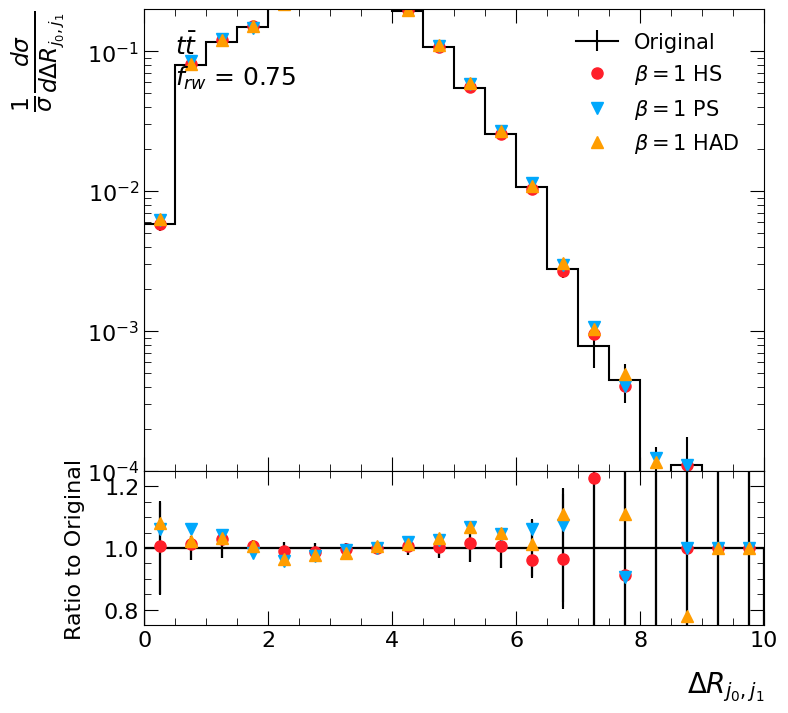

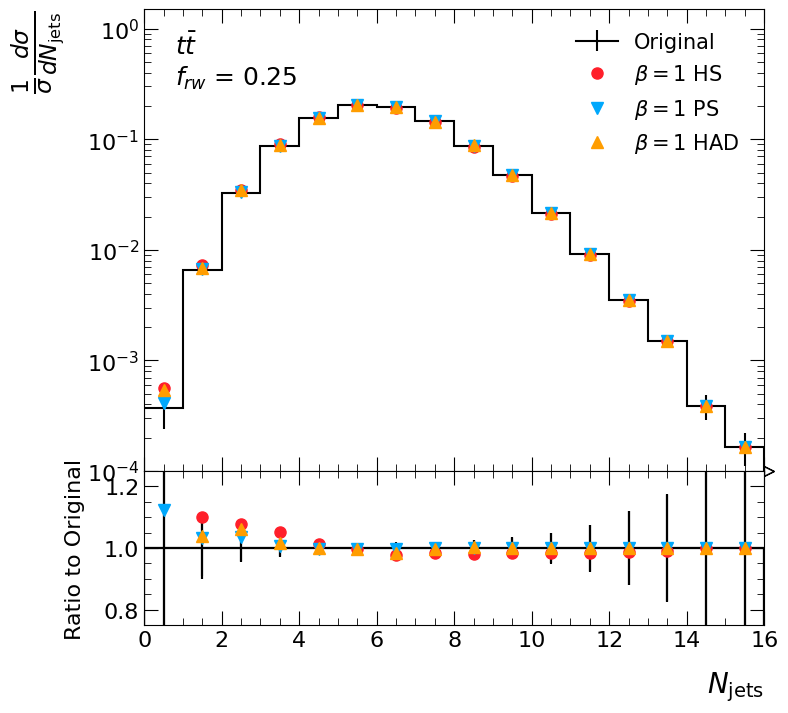

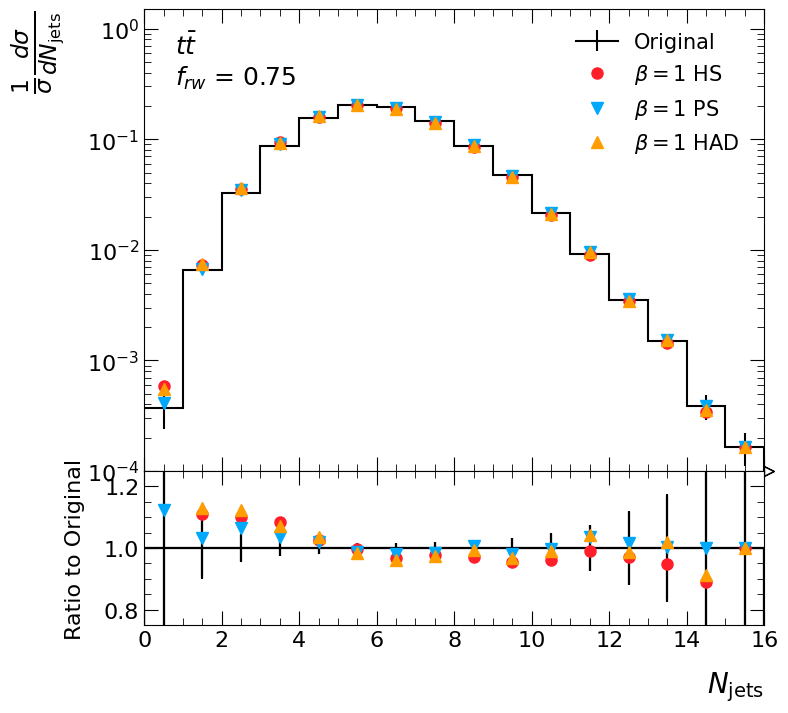

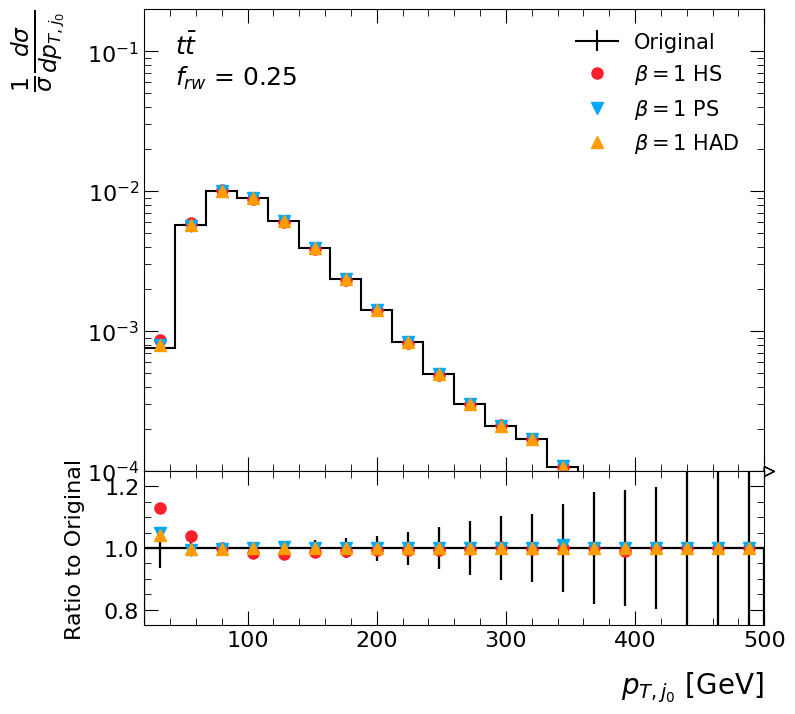

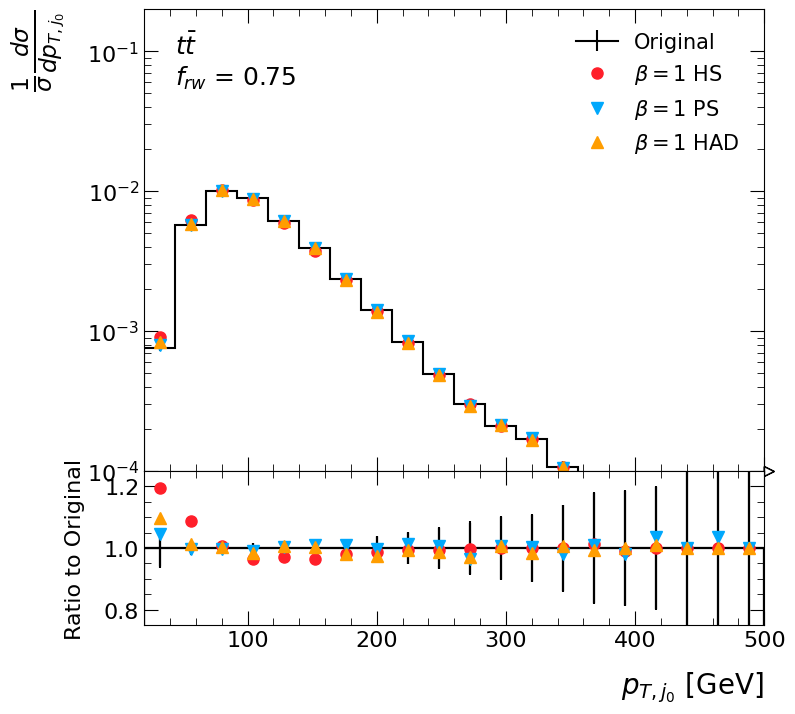

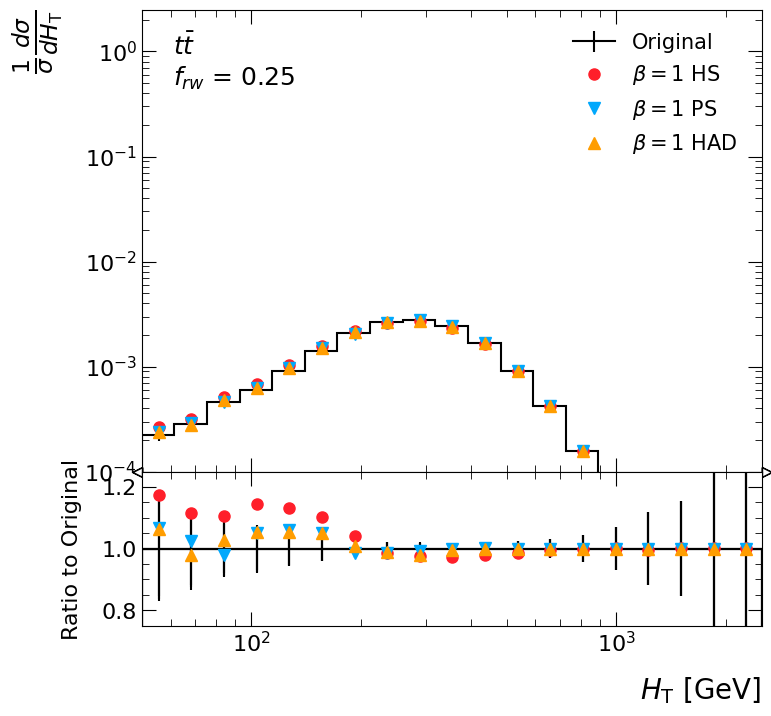

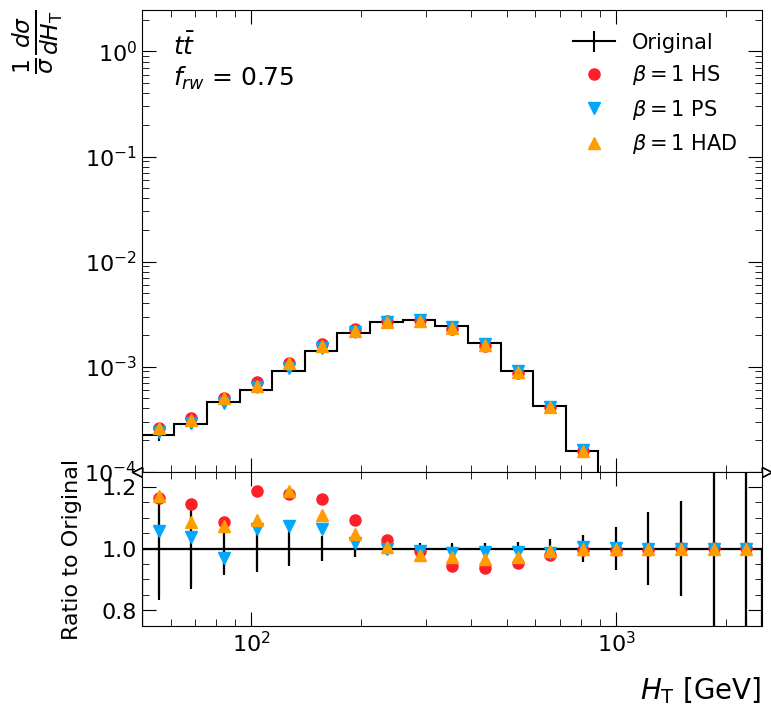

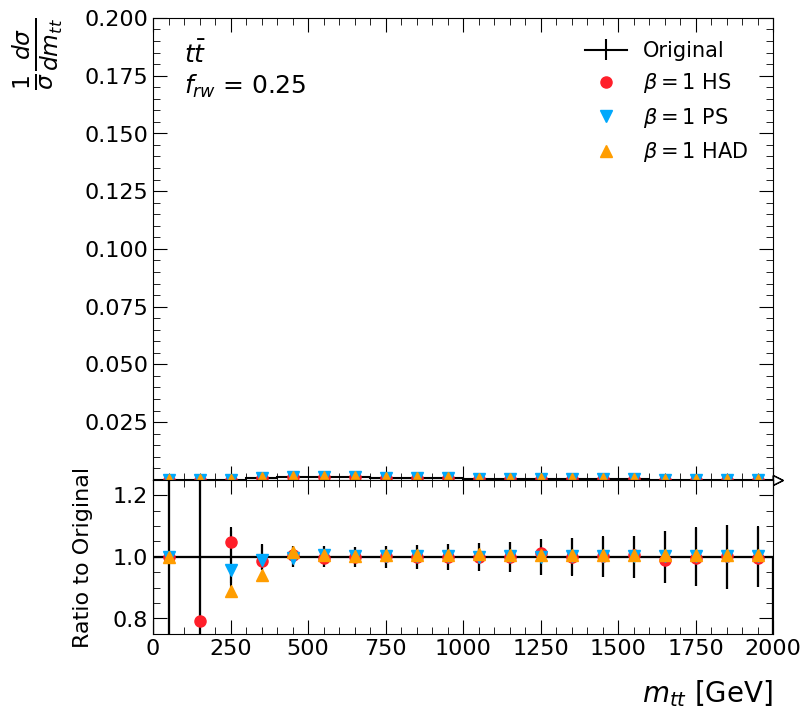

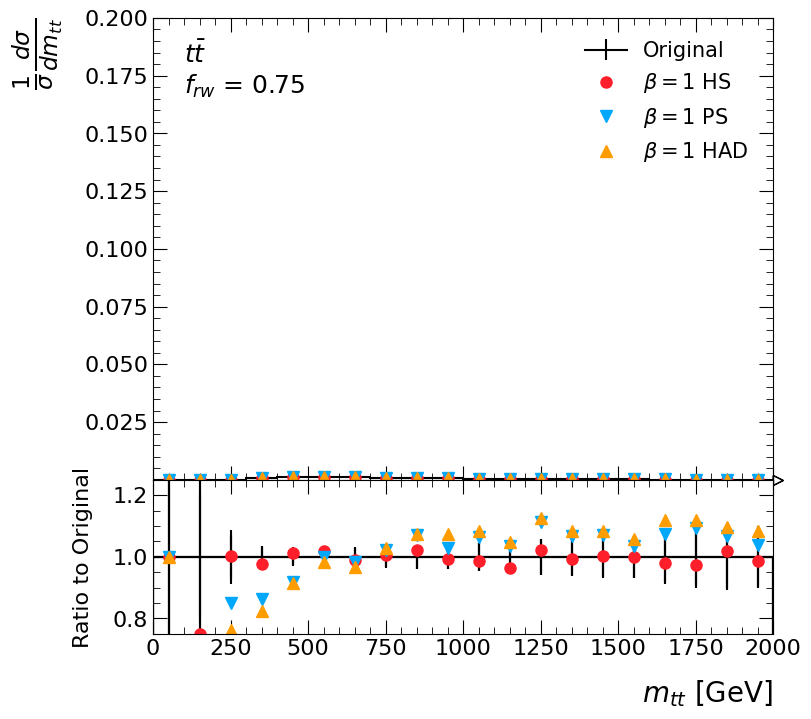

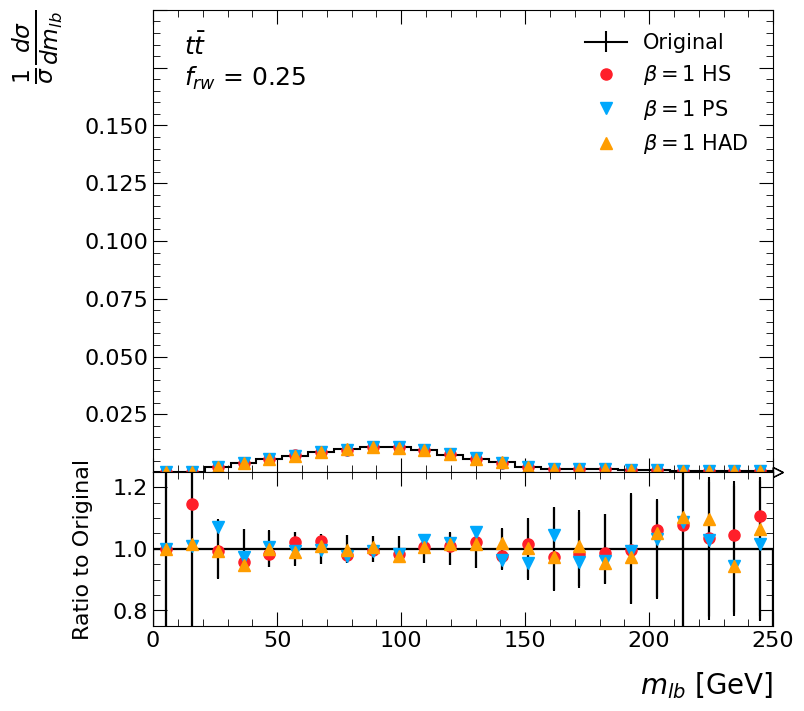

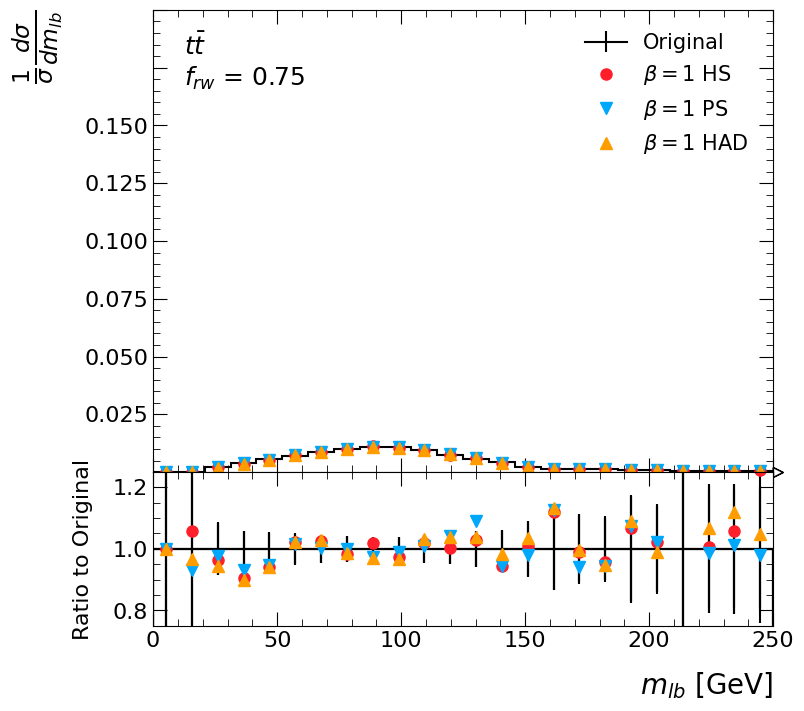

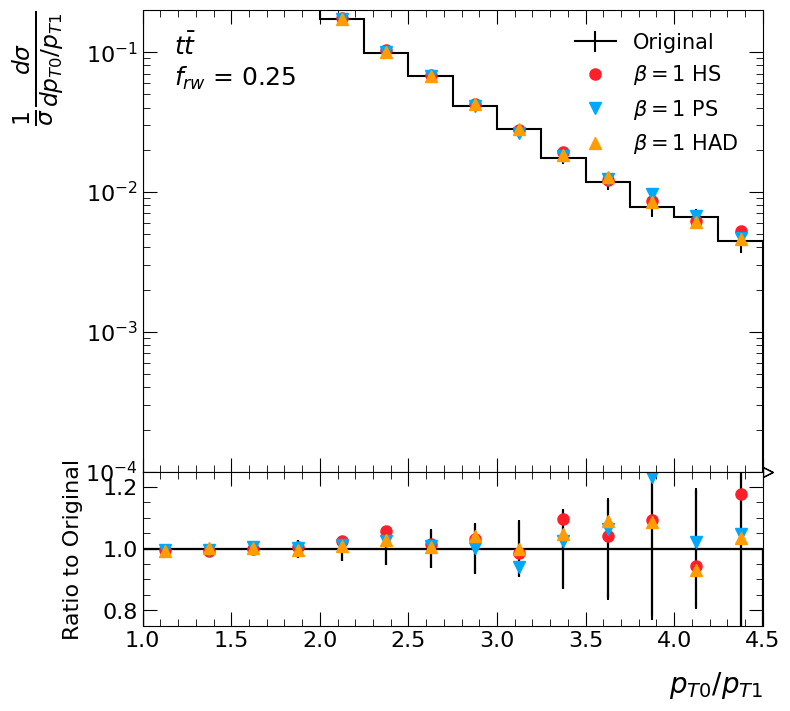

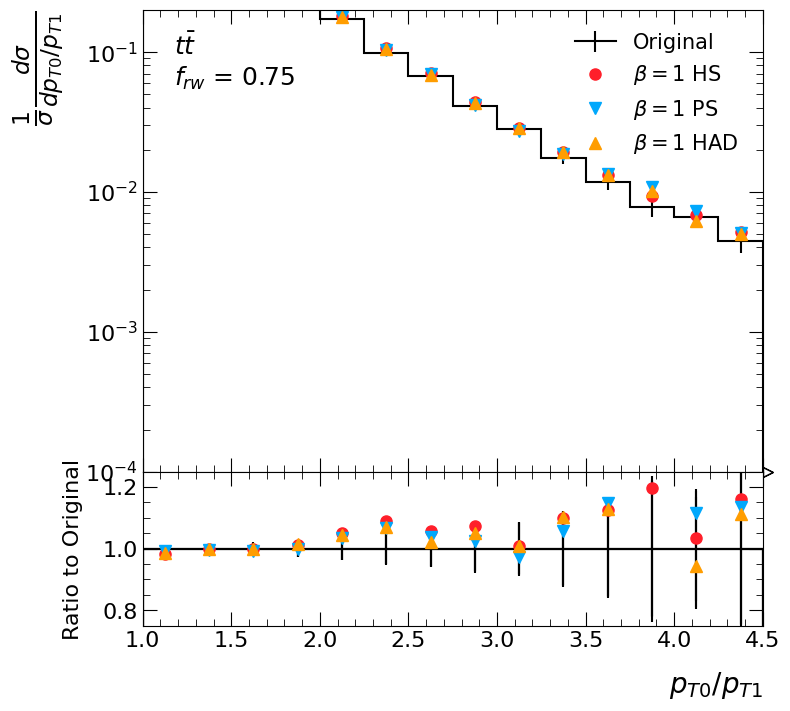

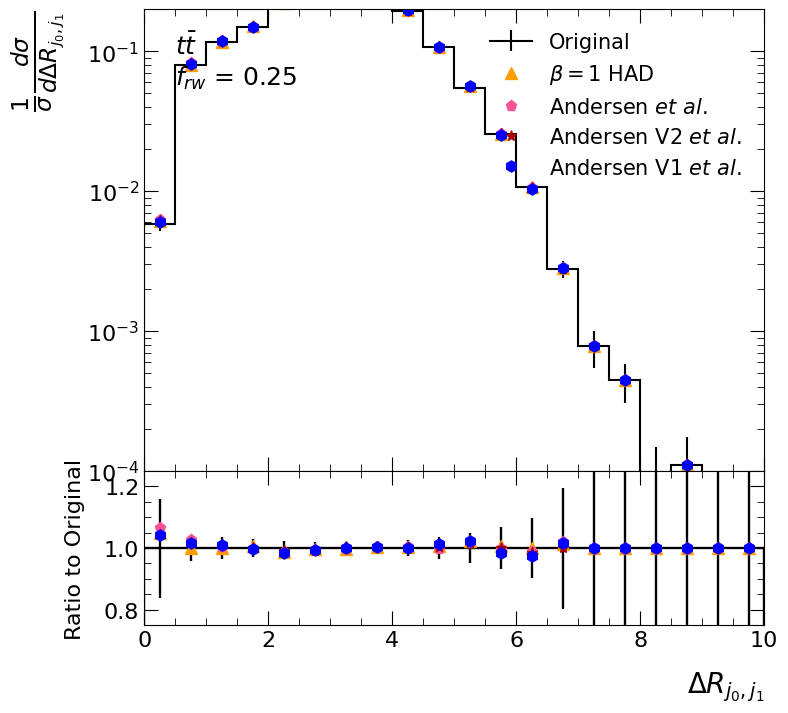

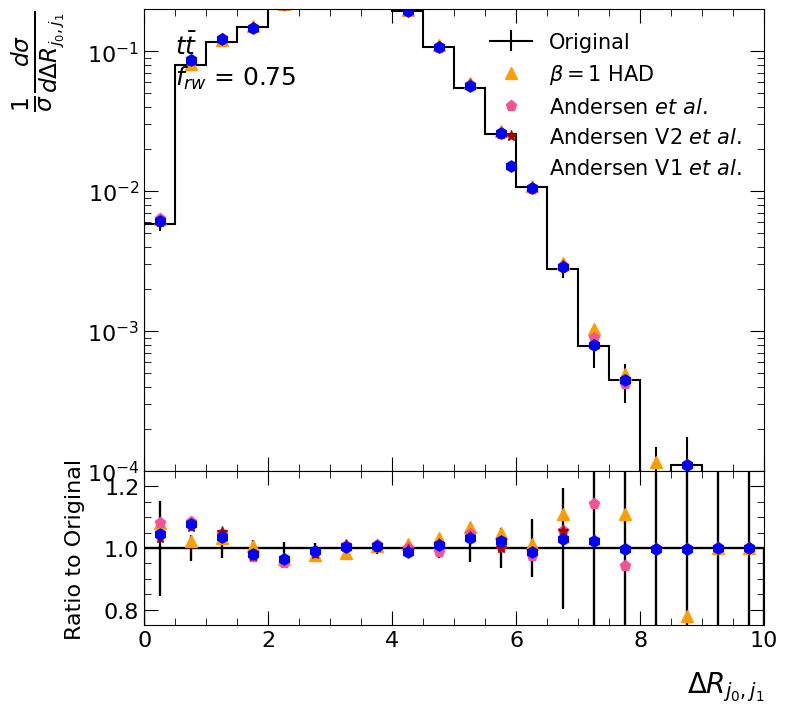

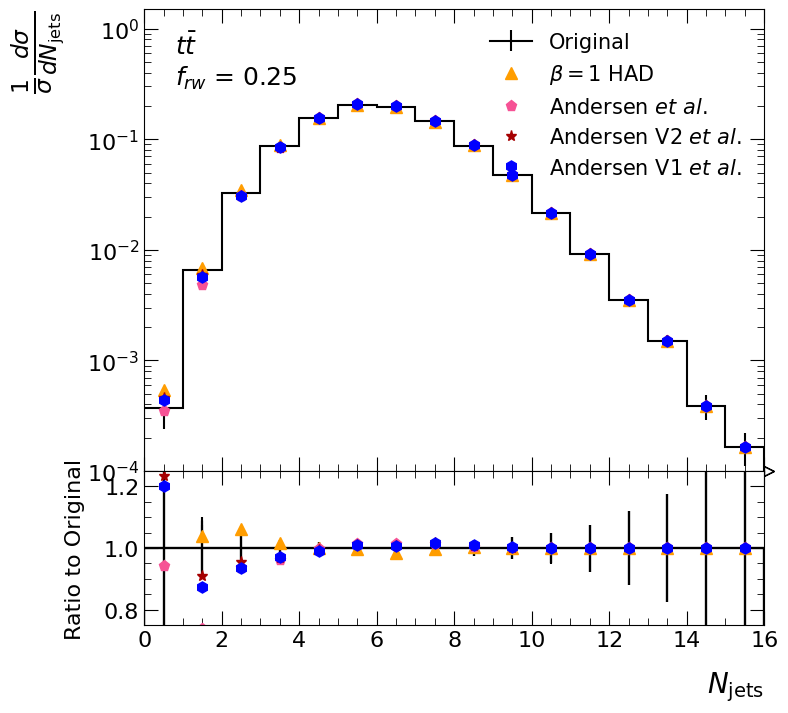

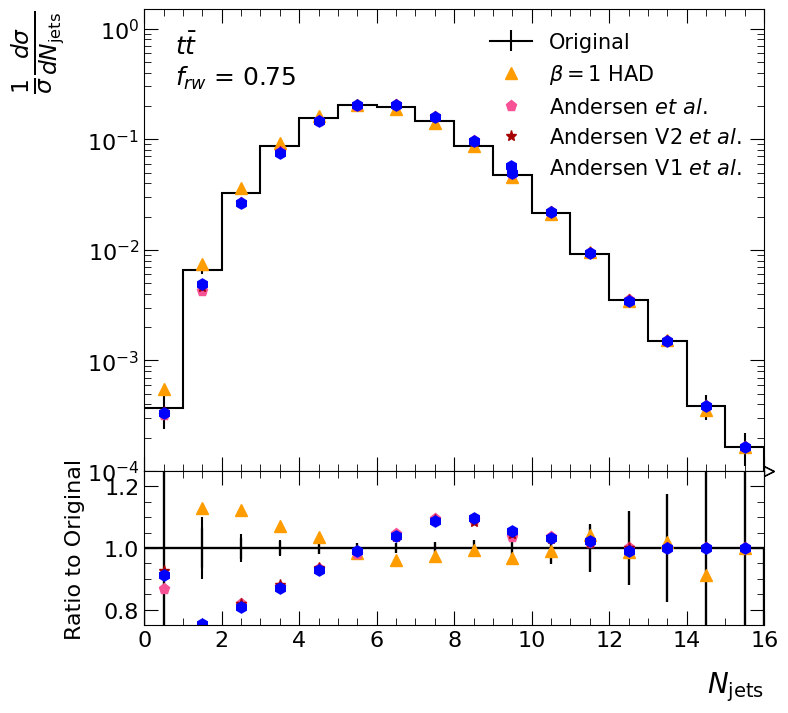

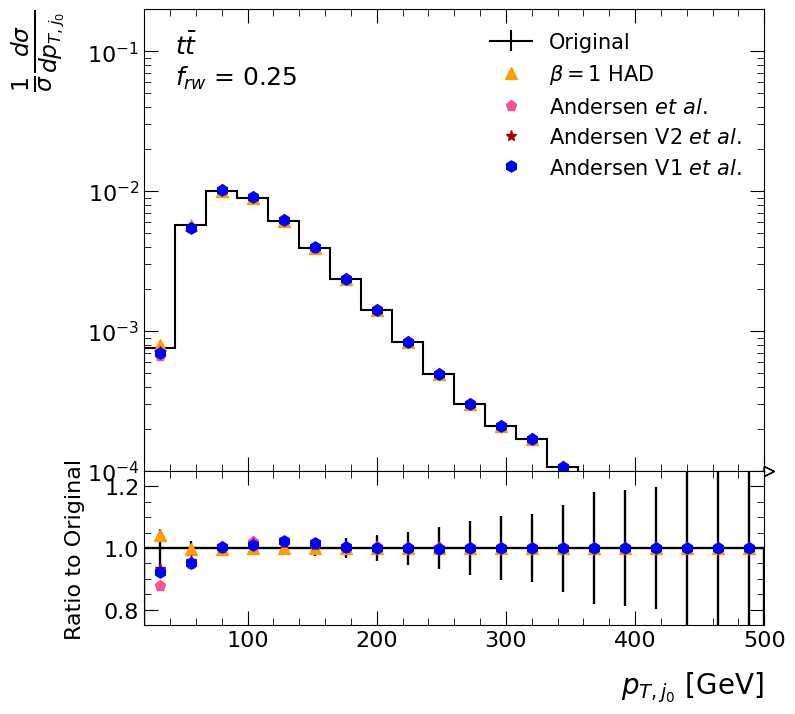

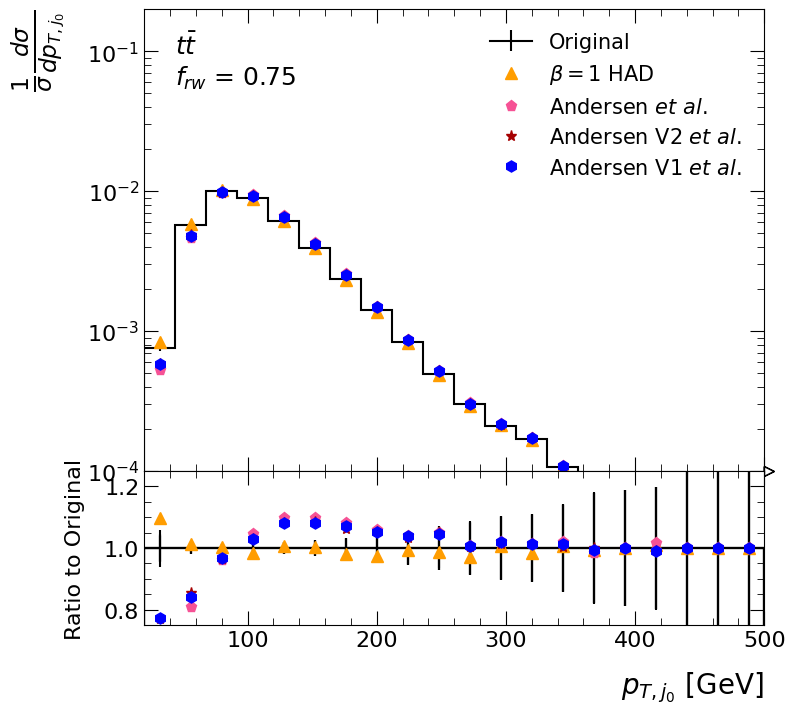

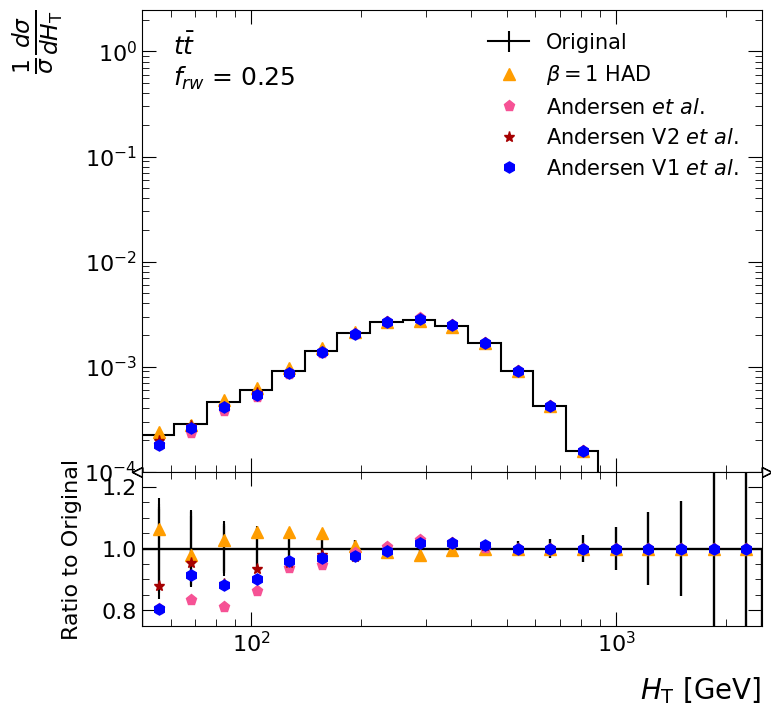

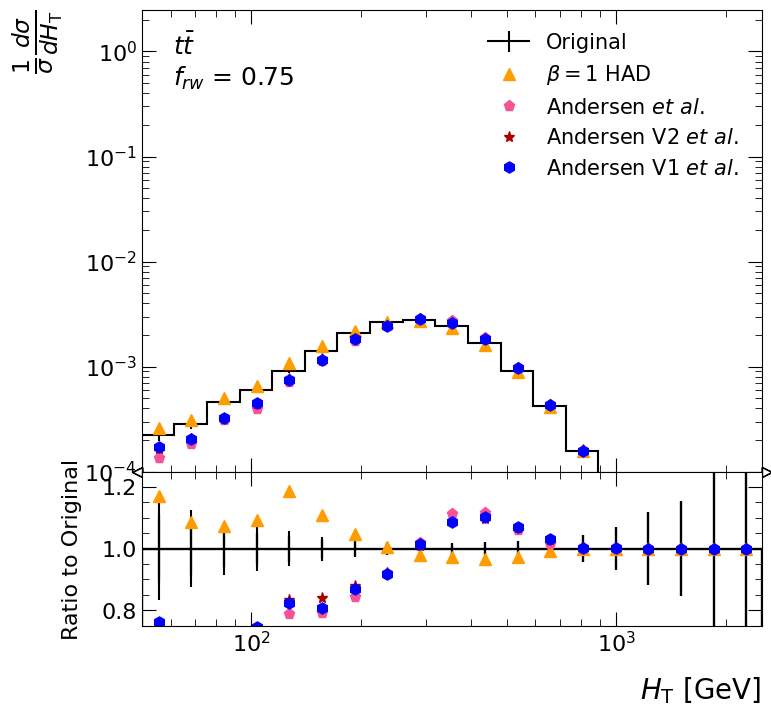

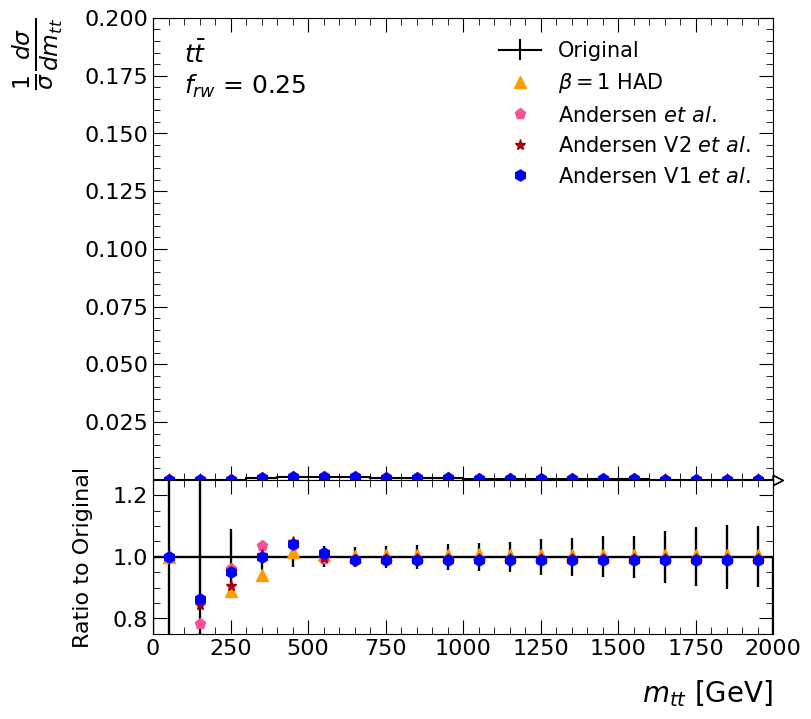

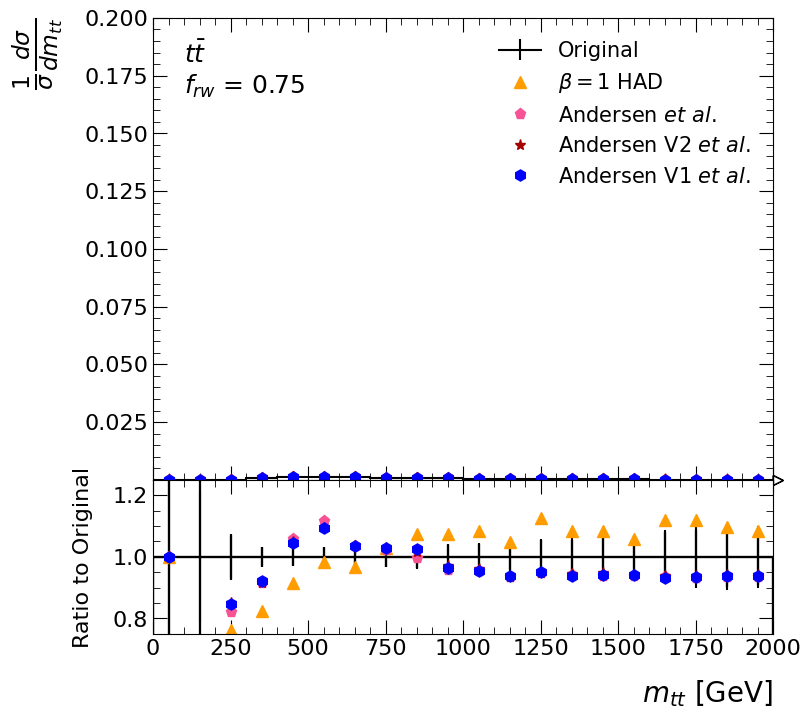

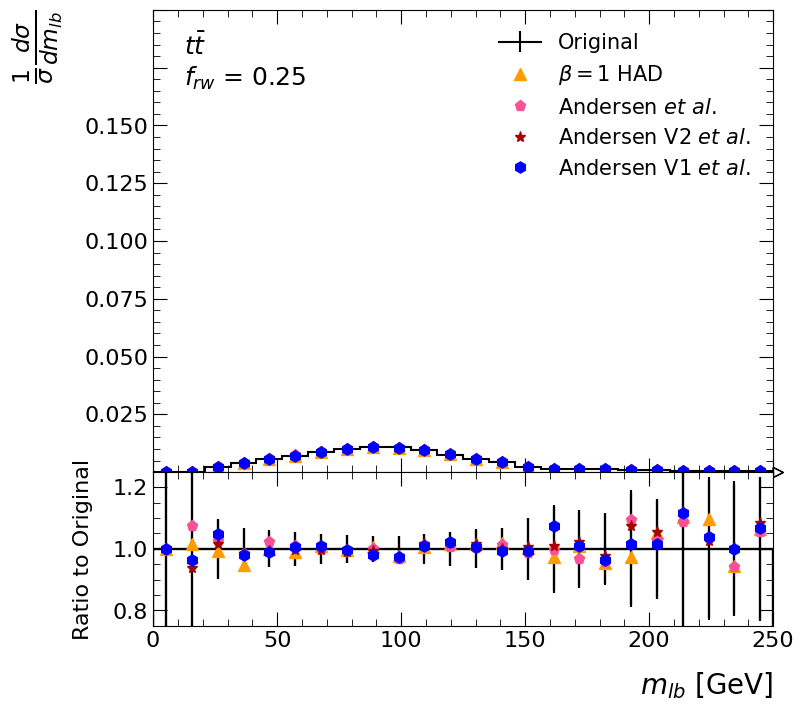

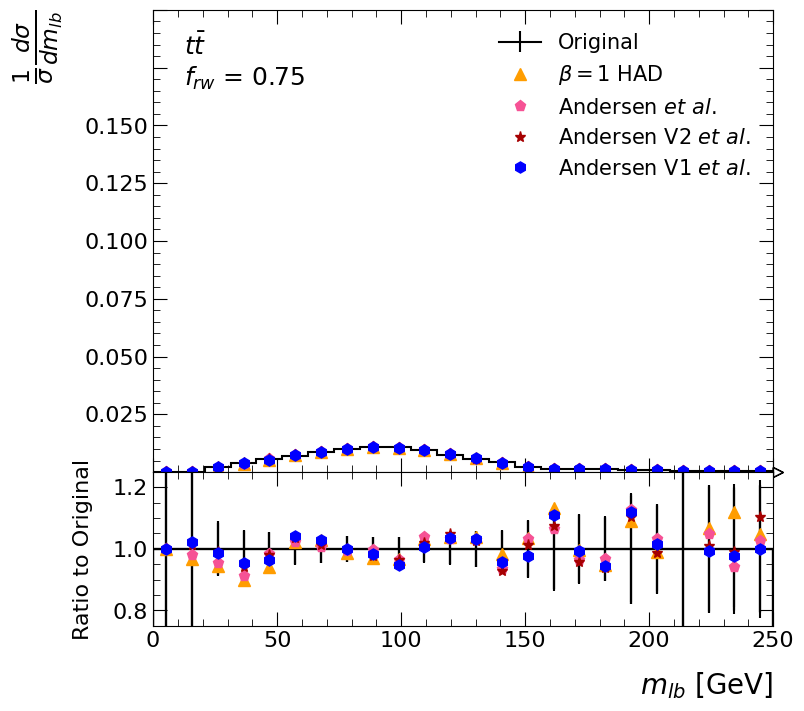

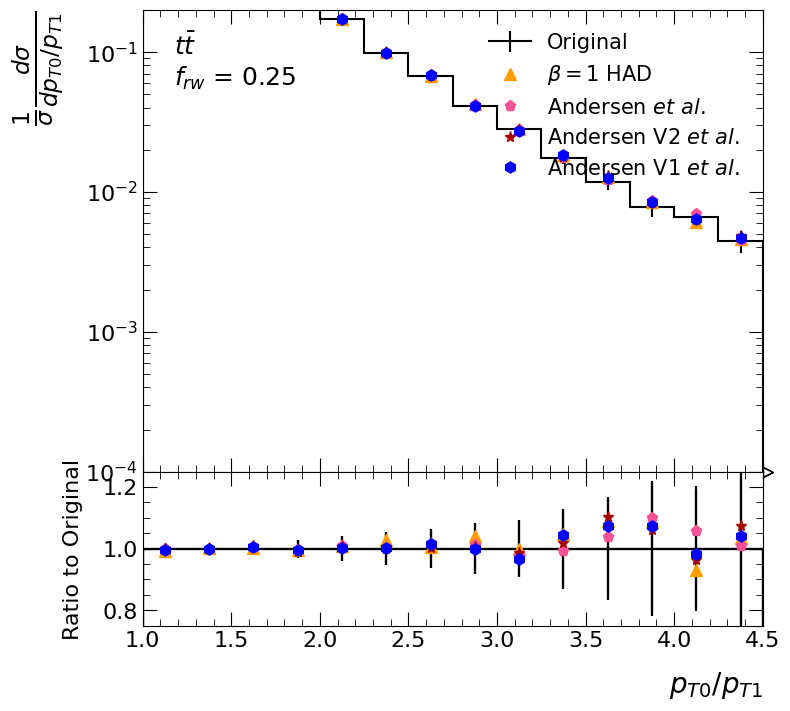

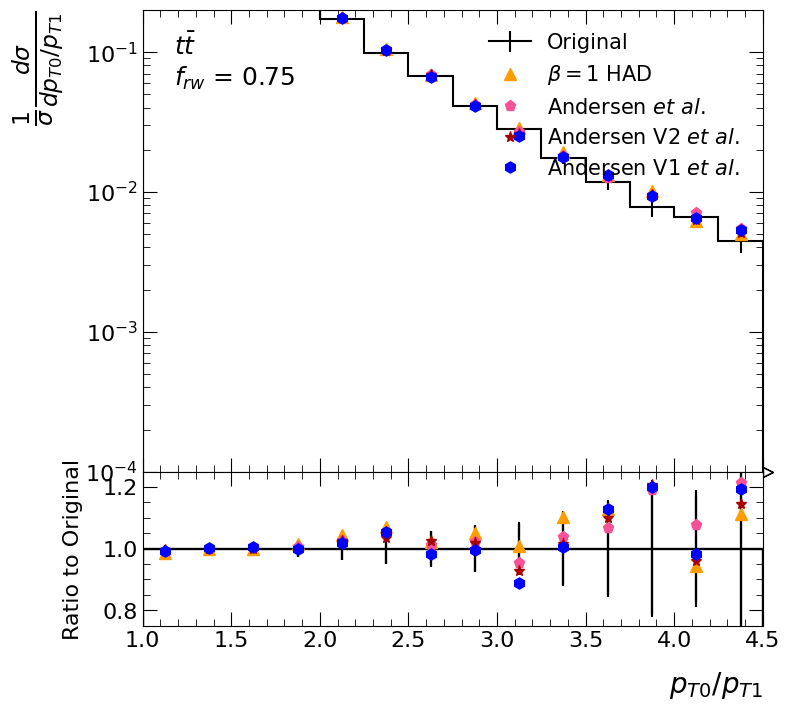

In [27]:
rwFracs = [0.25, 0.75]
for comparison in comparisonDict:
    for observable in obsDict:
        for rwFrac in rwFracs:       
            rw_dict_strings = comparisonDict[comparison]["weights"]

            processes = []
            datasets = []
            for sample in rw_dict_strings:
                datasets.append(dataFrames[sample])
                processes.append(dataFrames[sample]["process"])

            processWeights = processDict[processes[0]]["weights"]
            processTitle = processDict[processes[0]]["name"]
            isSameProcess = True
            for process in processes:
                if process != processes[0]:
                    print("Mixed processes -- this script requires rewriting to work in this context")
                    isSameProcess= False
                    break
            if not isSameProcess:
                break

            plot_diff_rw(obsDict[observable], datasets, processWeights, process_title = processTitle, title = comparison, channel = processes[0], rwFrac=rwFrac, obsName = observable)


In [28]:
##### plot multiple RW fraactions for the same sample
for comparison in comparisonDict:
    print(comparison)
    rw_dict_strings = comparisonDict[comparison]["weights"]
    for sample in rw_dict_strings:
        print(sample)
        dataset = dataFrames[sample]
        process = dataFrames[sample]["process"]
        rw_dict_strings = comparisonDict[comparison]["weights"]
        for observable in obsDict:
            plot_same_rw_all(obsDict[observable], dataset["df"], weights_orig_ttbar)


stages
$t\bar{t}$ $\beta=1$ HAD 


IndexError: cannot slice NumpyArray (of length 99256) with 'logy': not an array of records